<a href="https://colab.research.google.com/github/Ak13-moneyguy/mnist_classifier/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.model_selection import *
import matplotlib.pyplot as plt
import numpy as np
import tensorflow.keras as keras
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.metrics import *
from sklearn.linear_model import SGDClassifier

In [3]:
mnist = fetch_openml('mnist_784')

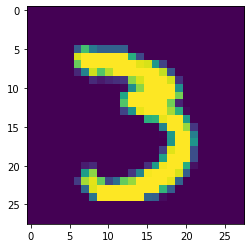

In [4]:
y = [float(i) for i in mnist['target']]
X = mnist['data']
some_digit = X[30090].reshape(28,28)
plt.imshow(some_digit)

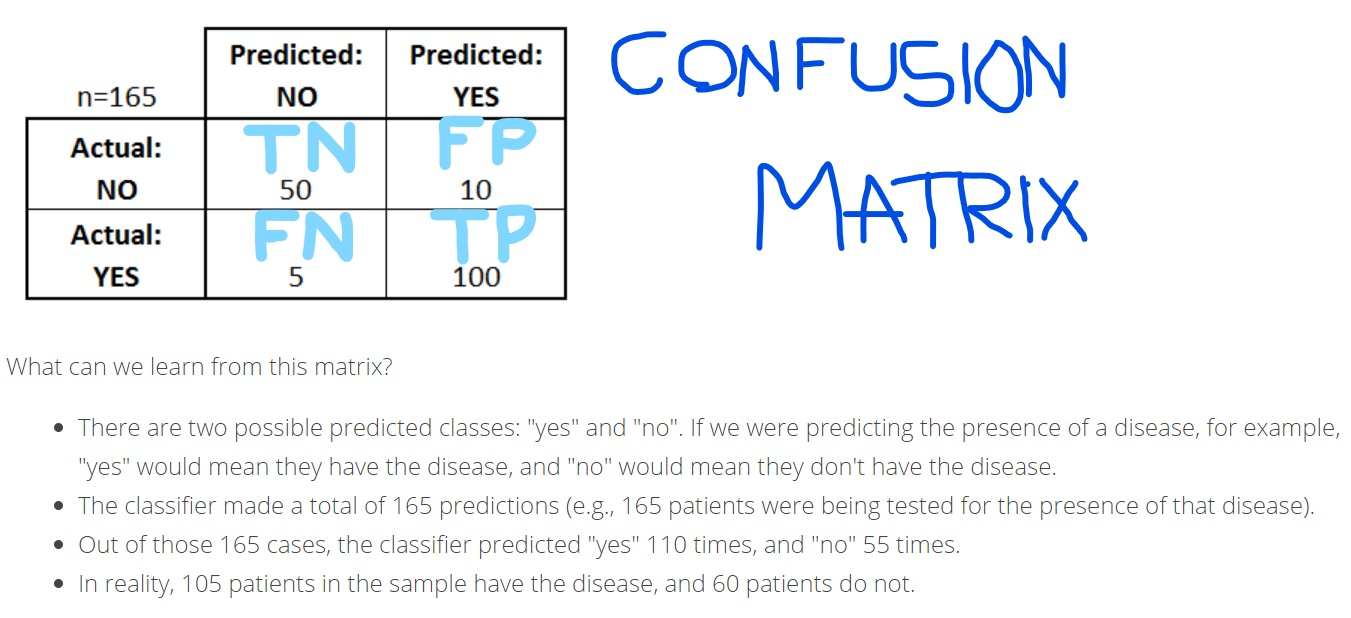

In [5]:
X = np.array(X)
y = np.array(y)
print(X.shape,"\n",y.shape)

(70000, 784) 
 (70000,)


In [8]:
model = keras.Sequential([
                          keras.layers.Dense(32, activation='relu'),
                          keras.layers.Dense(64, activation='relu'),
                          keras.layers.Dense(128, activation='sigmoid'),
                          keras.layers.Dense(512, activation='sigmoid'),
                          keras.layers.Dense(256, activation='sigmoid'),
                          keras.layers.Dropout(0.3),
                          keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[keras.metrics.BinaryAccuracy(), keras.metrics.FalseNegatives(), 'accuracy'])

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [10]:
history = model.fit(x_train, y_train, verbose=1, validation_split=0.2, epochs=50)

Epoch 1/50
1488/1488 [==============================] - 8s 6ms/step - loss: 0.1911 - binary_accuracy: 0.9891 - false_negatives_1: 3049.0000 - accuracy: 0.9442 - val_loss: 0.1998 - val_binary_accuracy: 0.9890 - val_false_negatives_1: 750.0000 - val_accuracy: 0.9427
Epoch 2/50
1488/1488 [==============================] - 8s 6ms/step - loss: 0.1845 - binary_accuracy: 0.9895 - false_negatives_1: 2938.0000 - accuracy: 0.9469 - val_loss: 0.2106 - val_binary_accuracy: 0.9876 - val_false_negatives_1: 844.0000 - val_accuracy: 0.9355
Epoch 3/50
1488/1488 [==============================] - 9s 6ms/step - loss: 0.1764 - binary_accuracy: 0.9899 - false_negatives_1: 2842.0000 - accuracy: 0.9479 - val_loss: 0.1854 - val_binary_accuracy: 0.9896 - val_false_negatives_1: 699.0000 - val_accuracy: 0.9475
Epoch 4/50
1488/1488 [==============================] - 9s 6ms/step - loss: 0.1753 - binary_accuracy: 0.9898 - false_negatives_1: 2849.0000 - accuracy: 0.9476 - val_loss: 0.2259 - val_binary_accuracy: 0.98

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_5 (Dense)              (None, 32)                25120     
_________________________________________________________________
dense_6 (Dense)              (None, 64)                2112      
_________________________________________________________________
dense_7 (Dense)              (None, 128)               8320      
_________________________________________________________________
dense_8 (Dense)              (None, 512)               66048     
_________________________________________________________________
dense_9 (Dense)              (None, 256)               131328    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_10 (Dense)             (None, 10)               

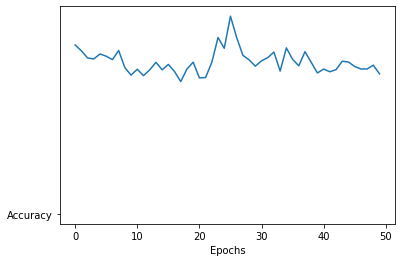

In [14]:
print(model.summary())

plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.plot('Error')

In [29]:
nn_pred = model.predict(x_test)
nn_pred

ones = np.argmax(nn_pred, axis=1)

pred = np.zeros(nn_pred.shape)
for i in range(pred.shape[0]):
  pred[i][ones[i]] = 1

y_test - pred

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [35]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1035
           1       0.98      0.98      0.98      1205
           2       0.92      0.94      0.93      1019
           3       0.93      0.94      0.94      1081
           4       0.90      0.96      0.93       968
           5       0.95      0.93      0.94       970
           6       0.97      0.97      0.97      1009
           7       0.94      0.96      0.95      1110
           8       0.92      0.89      0.91      1016
           9       0.95      0.89      0.92      1087

   micro avg       0.94      0.94      0.94     10500
   macro avg       0.94      0.94      0.94     10500
weighted avg       0.94      0.94      0.94     10500
 samples avg       0.94      0.94      0.94     10500

